In [3]:
# Derivadas parciales para regresión lineal
# ####################################################################
def der_parcial_1(xs: list, ys: list) -> tuple[float, float, float]:
    """Retorna los coeficientes de la ecuación de la derivada parcial con respecto al parámetro 1 al reemplazar los valores ``xs`` y ``ys``. La ecuación es de la forma:
    c_1 * a_1 + c_0 * a_0 = c_ind


    ## Parameters

    ``xs``: lista de valores de x.

    ``ys``: lista de valores de y.

    ## Return

    ``c_1``: coeficiente del parámetro 1.

    ``c_0``: coeficiente del parámetro 0.

    ``c_ind``: coeficiente del término independiente.

    """

    # coeficiente del término independiente
    c_ind = sum(ys)

    # coeficiente del parámetro 1
    c_1 = sum(xs)

    # coeficiente del parámetro 0
    c_0 = len(xs)

    return (c_1, c_0, c_ind)


def der_parcial_0(xs: list, ys: list) -> tuple[float, float, float]:
    """Retorna los coeficientes de la ecuación de la derivada parcial con respecto al parámetro 0 al reemplazar los valores ``xs`` y ``ys``. La ecuación es de la forma:
    c_1 * a_1 + c_0 * a_0 = c_ind


    ## Parameters

    ``xs``: lista de valores de x.

    ``ys``: lista de valores de y.

    ## Return

    ``c_1``: coeficiente del parámetro 1.

    ``c_0``: coeficiente del parámetro 0.

    ``c_ind``: coeficiente del término independiente.

    """
    c_1 = 0
    c_0 = 0
    c_ind = 0
    for xi, yi in zip(xs, ys):
        # coeficiente del término independiente
        c_ind += xi * yi

        # coeficiente del parámetro 1
        c_1 += xi * xi

        # coeficiente del parámetro 0
        c_0 += xi

    return (c_1, c_0, c_ind)

In [4]:
import numpy as np


# ####################################################################
def ajustar_min_cuadrados(
    xs: list,
    ys: list,
    gradiente: list,  # cada elemento debe ser una función (callable) con firma (xs, ys) -> (c1, c0, c_ind)
) -> None:
    """Resuelve el sistema de ecuaciones para encontrar los parámetros del método de mínimos cuadrados. Plantea el sistema de ecuaciones lineales al reemplazar los valores de ``xs`` y ``ys`` en las derivadas parciales.

    ## Parameters

    ``xs``: lista con los valores de x.

    ``ys``: lista con los valores de y.

    ``gradiente``: lista con las funciones de derivadas parciales de ``fcn``.
    [IMPORTANTE] Cada función debe ser de la forma ``der_parcial(xi, yi)->``.

    ## Return

    ``solucion``: vector con la solución del sistema de ecuaciones lineales.

    """

    assert len(xs) == len(ys), "xs y ys deben tener la misma longitud."

    n = len(xs)

    num_pars = len(gradiente)
    print(f"Se ajustarán {num_pars} parámetros.")
    # --- construir matriz A y vector b
    Ab = np.zeros((num_pars, num_pars + 1), dtype=float)

    for i, der_parcial in enumerate(gradiente):
        assert callable(der_parcial), "Cada derivada parcial debe ser una función."

        Ab[i, :] = der_parcial(xs, ys)

    # --- resolver el sistema de ecuaciones lineales

    coef = np.linalg.solve(Ab[:, :-1], Ab[:, -1])

    return coef

# reemplazar por el conjunto de datos 1 
x = [-4.00, -3.98, -3.96, -3.95, -3.93, -3.91, -3.89, -3.88, -3.86, -3.84, -3.82, -3.81, -3.79, -3.77, -3.75, -3.74, -3.72, -3.70, -3.68, -3.67, -3.65, -3.63, -3.61, -3.60, -3.58, -3.56, -3.54, -3.53, -3.51, -3.49, -3.47, -3.46, -3.44, -3.42, -3.40, -3.39, -3.37, -3.35, -3.33, -3.32, -3.30, -3.28, -3.26, -3.25, -3.23, -3.21, -3.19, -3.18, -3.16, -3.14, -3.12, -3.11, -3.09, -3.07, -3.05, -3.04, -3.02, -3.00, -2.98, -2.96, -2.95, -2.93, -2.91, -2.89, -2.88, -2.86, -2.84, -2.82, -2.81, -2.79, -2.77, -2.75, -2.74, -2.72, -2.70, -2.68, -2.67, -2.65, -2.63, -2.61, -2.60, -2.58, -2.56, -2.54, -2.53, -2.51, -2.49, -2.47, -2.46, -2.44, -2.42, -2.40, -2.39, -2.37, -2.35, -2.33, -2.32, -2.30, -2.28, -2.26, -2.25, -2.23, -2.21, -2.19, -2.18, -2.16, -2.14, -2.12, -2.11, -2.09, -2.07, -2.05, -2.04, -2.02, -2.00, -1.98, -1.96, -1.95, -1.93, -1.91, -1.89, -1.88, -1.86, -1.84, -1.82, -1.81, -1.79, -1.77, -1.75, -1.74, -1.72, -1.70, -1.68, -1.67, -1.65, -1.63, -1.61, -1.60, -1.58, -1.56, -1.54, -1.53, -1.51, -1.49, -1.47, -1.46, -1.44, -1.42, -1.40, -1.39, -1.37, -1.35, -1.33, -1.32, -1.30, -1.28, -1.26, -1.25, -1.23, -1.21, -1.19, -1.18, -1.16, -1.14, -1.12, -1.11, -1.09, -1.07, -1.05, -1.04, -1.02, -1.00, -0.98, -0.96, -0.95, -0.93, -0.91, -0.89, -0.88, -0.86, -0.84, -0.82, -0.81, -0.79, -0.77, -0.75, -0.74, -0.72, -0.70, -0.68, -0.67, -0.65, -0.63, -0.61, -0.60, -0.58, -0.56, -0.54, -0.53, -0.51, -0.49, -0.47, -0.46, -0.44, -0.42, -0.40, -0.39, -0.37, -0.35, -0.33, -0.32, -0.30, -0.28, -0.26, -0.25, -0.23, -0.21, -0.19, -0.18, -0.16, -0.14, -0.12, -0.11, -0.09, -0.07, -0.05, -0.04, -0.02, 0.00, 0.02, 0.04, 0.05, 0.07, 0.09, 0.11, 0.12, 0.14, 0.16, 0.18, 0.19, 0.21, 0.23, 0.25, 0.26, 0.28, 0.30, 0.32, 0.33, 0.35, 0.37, 0.39, 0.40, 0.42, 0.44, 0.46, 0.47, 0.49, 0.51, 0.53, 0.54, 0.56, 0.58, 0.60, 0.61, 0.63, 0.65, 0.67, 0.68, 0.70, 0.72, 0.74, 0.75, 0.77, 0.79, 0.81, 0.82, 0.84, 0.86, 0.88, 0.89, 0.91, 0.93, 0.95, 0.96, 0.98, 1.00, 1.02, 1.04, 1.05, 1.07, 1.09, 1.11, 1.12, 1.14, 1.16, 1.18, 1.19, 1.21, 1.23, 1.25, 1.26, 1.28, 1.30, 1.32, 1.33, 1.35, 1.37, 1.39, 1.40, 1.42, 1.44, 1.46, 1.47, 1.49, 1.51, 1.53, 1.54, 1.56, 1.58, 1.60, 1.61, 1.63, 1.65, 1.67, 1.68, 1.70, 1.72, 1.74, 1.75, 1.77, 1.79, 1.81, 1.82, 1.84, 1.86, 1.88, 1.89, 1.91, 1.93, 1.95, 1.96, 1.98, 2.00, 2.02, 2.04, 2.05, 2.07, 2.09, 2.11, 2.12, 2.14, 2.16, 2.18, 2.19, 2.21, 2.23, 2.25, 2.26, 2.28, 2.30, 2.32, 2.33, 2.35, 2.37, 2.39, 2.40, 2.42, 2.44, 2.46, 2.47, 2.49, 2.51, 2.53, 2.54, 2.56, 2.58, 2.60, 2.61, 2.63, 2.65, 2.67, 2.68, 2.70, 2.72, 2.74, 2.75, 2.77, 2.79, 2.81, 2.82, 2.84, 2.86, 2.88, 2.89, 2.91, 2.93, 2.95, 2.96, 2.98, 3.00]
y = [-48.95, -58.04, -50.12, -53.90, -47.49, -48.17, -51.37, -47.83, -50.33, -41.01, -44.98, -41.86, -43.88, -47.20, -41.22, -38.51, -37.75, -40.94, -40.73, -37.92, -40.70, -38.42, -29.95, -39.21, -39.29, -33.40, -32.08, -33.42, -32.82, -33.10, -34.46, -31.03, -34.52, -33.15, -24.52, -31.02, -31.38, -27.09, -28.96, -29.23, -23.23, -25.87, -24.70, -22.24, -23.61, -22.42, -21.17, -23.03, -25.07, -22.44, -20.98, -23.35, -23.39, -29.42, -22.30, -21.41, -21.17, -19.02, -23.14, -20.46, -15.94, -13.97, -11.92, -15.24, -13.33, -18.13, -15.83, -14.68, -15.45, -14.69, -17.98, -11.00, -12.61, -12.04, -11.75, -7.20, -10.09, -9.98, -9.41, -2.34, -12.72, -10.86, -15.45, -15.03, -8.95, -13.17, -11.53, -5.30, -5.23, -8.70, -3.94, -11.88, -5.74, -8.66, -4.28, -12.33, -3.23, -11.21, -8.40, -6.79, -8.76, -8.82, -10.05, -5.38, -9.14, -2.07, -5.28, -6.57, -5.56, -7.28, -3.63, -4.78, -5.53, -8.23, -4.98, 0.13, -9.37, -10.57, -5.75, -2.69, 1.76, -8.28, -6.89, -7.72, -7.20, -0.67, 0.52, 5.07, -8.16, -2.11, 0.54, -6.43, 0.60, -4.09, -0.51, -0.74, 2.98, -0.31, -2.66, 0.97, 0.31, -3.92, 1.65, -8.27, -0.19, -8.02, 1.05, -8.08, -8.22, -5.15, -2.48, -7.50, 6.93, -3.62, -4.12, 0.37, -3.92, 1.51, -2.48, 1.10, -0.59, -0.51, -0.19, -2.96, -1.77, -2.94, 1.15, -0.18, -4.87, 3.37, -4.41, -5.55, -5.21, -0.48, 4.01, -0.45, -0.35, -3.18, -3.34, -1.79, -5.01, -3.74, -7.65, -5.96, -1.15, -5.18, -7.22, -0.82, -6.97, -4.13, -1.35, -2.40, -2.70, -9.66, -5.21, 1.24, -9.89, -5.96, -4.58, -1.73, -4.33, -1.43, -3.81, 1.99, -3.46, -2.37, -3.38, -0.26, -3.25, -3.36, 0.21, -5.48, -3.82, -0.33, -1.42, 3.17, -2.72, -3.43, -9.56, -9.83, 0.52, 0.85, -4.41, -2.71, -6.12, -3.08, -3.76, 2.93, 2.18, -7.49, 0.22, -0.73, -5.46, -3.87, -2.52, -4.57, -2.15, -3.10, 2.57, -2.07, -0.25, -5.91, 1.40, 2.49, -6.80, -4.44, -1.69, -0.64, 1.93, -0.73, -0.47, 0.08, -3.29, 0.47, -3.67, -1.40, -0.92, -1.21, -1.86, 0.05, 1.27, 1.18, 2.79, -2.01, -2.33, 2.01, 2.33, 0.68, 1.93, 2.82, -5.70, 2.78, -4.66, -5.70, -0.09, -1.13, 4.56, 0.10, 1.33, 0.94, -2.36, 0.05, 3.96, 5.13, 3.67, 5.63, 2.12, 4.68, 5.44, 9.31, -1.83, 5.57, 6.86, 5.27, 8.66, 0.22, 14.13, 7.70, 5.00, 7.03, 4.90, 9.86, 2.71, 9.62, 4.56, 11.28, 8.63, 9.97, 4.41, 10.69, 6.85, 8.81, 17.39, 12.25, 10.36, 13.74, 14.79, 13.20, 16.70, 18.11, 12.54, 17.34, 11.38, 19.25, 11.25, 14.35, 19.32, 14.02, 11.83, 15.27, 20.12, 17.86, 19.76, 23.73, 17.18, 22.32, 18.44, 18.95, 15.58, 21.45, 22.70, 19.47, 24.16, 25.82, 21.48, 21.51, 22.89, 19.85, 32.57, 23.80, 26.64, 25.91, 28.16, 29.17, 31.66, 28.22, 25.85, 31.01, 32.32, 39.18, 33.42, 36.73, 40.06, 36.05, 33.80, 34.98, 38.52, 29.97, 37.50, 42.37, 45.75, 47.18, 44.85, 46.65, 39.57, 53.93, 47.72, 50.09, 54.44, 50.20, 47.87, 51.14, 46.31, 49.73, 49.09, 51.00, 57.28, 52.55, 57.29, 58.37, 62.44, 62.24, 65.95, 60.79, 67.87, 61.48, 63.29, 66.71, 73.79, 69.58]

params = ajustar_min_cuadrados(x, y, [der_parcial_1, der_parcial_0])
print(params)

Se ajustarán 2 parámetros.
[10.15148247  5.74619124]


In [5]:
def pred(x):
    """Función de predicción basada en los parámetros ajustados."""
    return params[0] * x + params[1]

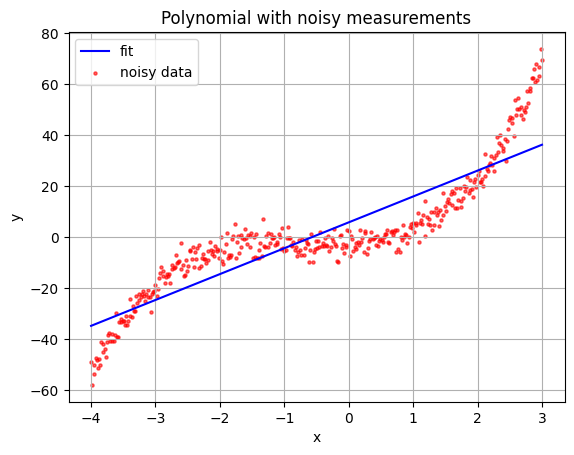

In [6]:
# plt.plot(x, y, label="polynomial")
import matplotlib.pyplot as plt

y_pred = [pred(xi) for xi in x]
plt.plot(x, y_pred, label="fit", color="blue")
plt.scatter(x, y, s=5, color="red", alpha=0.6, label="noisy data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial with noisy measurements")
plt.legend()
plt.grid(True)
plt.show()

Ingrese las derivadas parciales para la función cúbica modificada

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def der_parcial_red_2(xs: list, ys: list) -> tuple[float, float, float, float]:
    """Derivada parcial respecto al parámetro 'a' (asociado a x^3)."""
    c_2, c_1, c_0, c_ind = 0.0, 0.0, 0.0, 0.0
    for xi, yi in zip(xs, ys):
        c_2 += xi**6
        c_1 += xi**5
        c_0 += xi**3
        c_ind += (xi**3) * yi
    return (c_2, c_1, c_0, c_ind)

def der_parcial_red_1(xs: list, ys: list) -> tuple[float, float, float, float]:
    """Derivada parcial respecto al parámetro 'b' (asociado a x^2)."""
    c_2, c_1, c_0, c_ind = 0.0, 0.0, 0.0, 0.0
    for xi, yi in zip(xs, ys):
        c_2 += xi**5
        c_1 += xi**4
        c_0 += xi**2
        c_ind += (xi**2) * yi
    return (c_2, c_1, c_0, c_ind)

def der_parcial_red_0(xs: list, ys: list) -> tuple[float, float, float, float]:
    """Derivada parcial respecto al parámetro 'd' (término independiente)."""
    c_2, c_1, c_0, c_ind = 0.0, 0.0, 0.0, 0.0
    for xi, yi in zip(xs, ys):
        c_2 += xi**3
        c_1 += xi**2
        c_0 += 1
        c_ind += yi
    return (c_2, c_1, c_0, c_ind)

Se ajustarán 3 parámetros.
--- 1. FORMA MODIFICADA (COEFICIENTES) ---
a (para x^3): 1.6133549660191018
b (para x^2): 3.1791166592649462
d (término independiente): -3.0374487472211564

--- 2. ERRORES RELATIVOS ---
e_avg: 1.110938409349454
e_max: 38.12746006020532


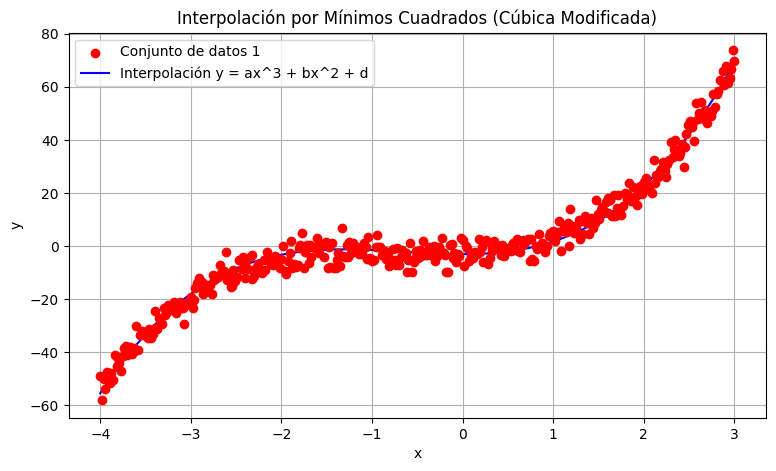

In [ ]:

gradiente_cubica = [der_parcial_red_2, der_parcial_red_1, der_parcial_red_0]

params_cubica = ajustar_min_cuadrados(x, y, gradiente_cubica)

a = params_cubica[0]
b = params_cubica[1]
d = params_cubica[2]


print("--- 1. FORMA MODIFICADA (COEFICIENTES) ---")
print(f"a (para x^3): {a}")
print(f"b (para x^2): {b}")
print(f"d (término independiente): {d}")

# Definimos la predicción
def pred_cubica(xi):
    return a * (xi**3) + b * (xi**2) + d

y_pred_cubica = [pred_cubica(xi) for xi in x]

# Calculamos los errores relativos
errores_relativos = [abs((yi - ypi) / yi) for yi, ypi in zip(y, y_pred_cubica)]
e_avg = np.mean(errores_relativos)
e_max = np.max(errores_relativos)

# Imprimimos los errores
print("\n--- 2. ERRORES RELATIVOS ---")
print(f"e_avg: {e_avg}")
print(f"e_max: {e_max}")

# Generamos el gráfico
x_line = np.linspace(min(x), max(x), 200)
y_line = [pred_cubica(xi) for xi in x_line]

plt.figure(figsize=(9, 5))
plt.scatter(x, y, color="red", label="Conjunto de datos 1", zorder=5)
plt.plot(x_line, y_line, color="blue", label="Interpolación y = ax^3 + bx^2 + d")
plt.title("Interpolación por Mínimos Cuadrados (Cúbica Modificada)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()